In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read in data
movies = pd.read_csv('movies.csv')

In [3]:
# basic info
print(movies.shape)
print(movies.dtypes)
print(movies.isnull().sum())
print(movies.describe())

(226, 14)
title                 object
url                   object
year                   int64
critics_choice_nom     int64
critics_choice_win     int64
bafta_nom              int64
bafta_win              int64
golden_globes_nom      int64
golden_globes_win      int64
pga_nom                int64
pga_win                int64
sag_nom                int64
sag_win                int64
oscar_win              int64
dtype: object
title                 0
url                   0
year                  0
critics_choice_nom    0
critics_choice_win    0
bafta_nom             0
bafta_win             0
golden_globes_nom     0
golden_globes_win     0
pga_nom               0
pga_win               0
sag_nom               0
sag_win               0
oscar_win             0
dtype: int64
              year  critics_choice_nom  critics_choice_win   bafta_nom  \
count   226.000000          226.000000          226.000000  226.000000   
mean   2013.269912            0.889381            0.137168    0.570796   

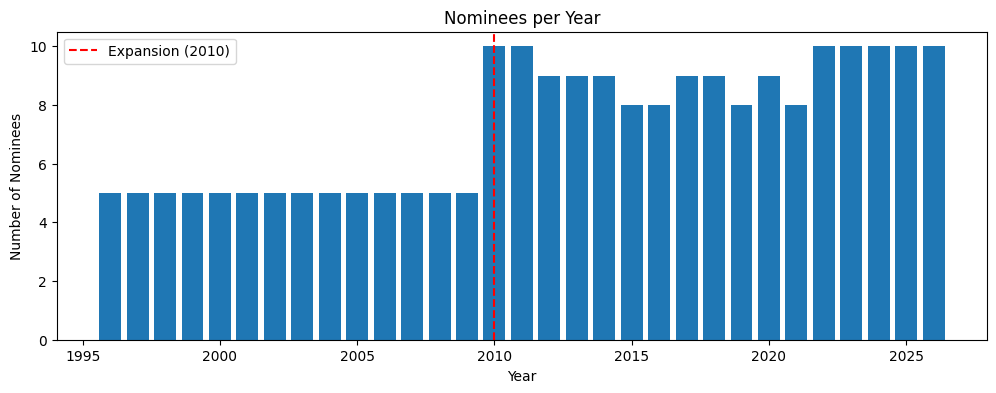

In [5]:
# oscar nominations changed from 5 best pictures to 10 in 2010
# separate these 2 eras
movies['era'] = movies['year'].apply(lambda x: 'post_2010' if x >= 2010 else 'pre_2010')

# nominees per year
nominees_per_year = movies.groupby('year').size().reset_index(name='num_nominees')
plt.figure(figsize=(12, 4))
plt.bar(nominees_per_year['year'], nominees_per_year['num_nominees'])
plt.axvline(x=2010, color='red', linestyle='--', label='Expansion (2010)')
plt.title('Nominees per Year')
plt.xlabel('Year')
plt.ylabel('Number of Nominees')
plt.legend()
plt.show()

                nom_rate  win_rate
critics_choice  0.889381  0.137168
bafta           0.570796  0.150442
golden_globes   0.641593  0.172566
pga             0.814159  0.141593
sag             0.451327  0.146018


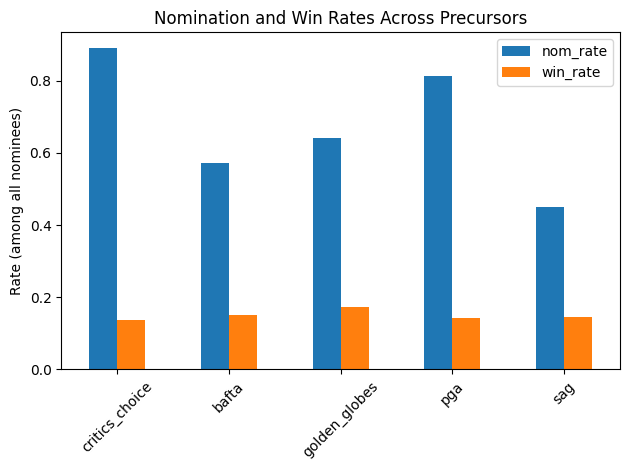

In [ ]:
# of all films nominated for the oscars, how did they perform at the precursors?
precursors = ['critics_choice', 'bafta', 'golden_globes', 'pga', 'sag']
nom_cols = [f'{p}_nom' for p in precursors]
win_cols = [f'{p}_win' for p in precursors]

base_rates = pd.DataFrame({
    'nom_rate': movies[nom_cols].mean().values,
    'win_rate': movies[win_cols].mean().values
}, index=precursors)

print(base_rates)

base_rates.plot(kind='bar', title='Nomination and Win Rates Across Precursors')
plt.ylabel('Rate (among all nominees)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

                Did Not Win Precursor  Won Precursor
critics_choice               0.061538       0.612903
bafta                        0.088542       0.411765
golden_globes                0.090909       0.358974
pga                          0.046392       0.687500
sag                          0.088083       0.424242


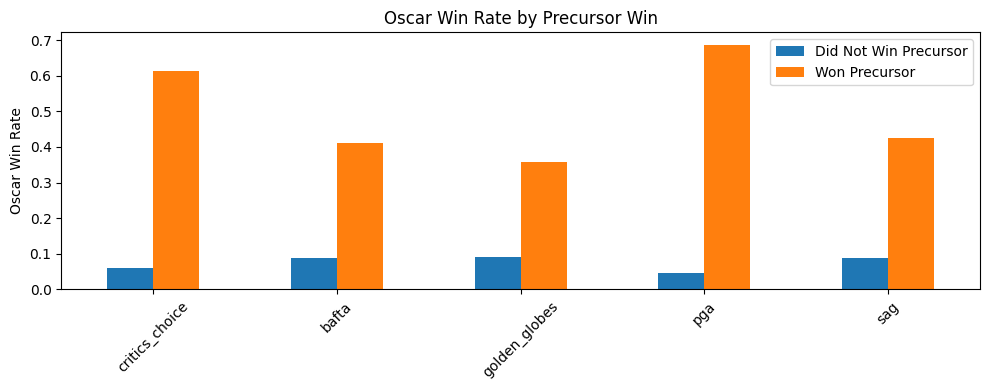

In [ ]:
# of films nominated/won at the precursors, how did they do at the oscars?
oscar_win_rates = {}
for p in precursors:
    win_col = f'{p}_win'
    rates = movies.groupby(win_col)['oscar_win'].mean()
    oscar_win_rates[p] = {
        'Did Not Win Precursor': rates.get(0, 0),
        'Won Precursor': rates.get(1, 0)
    }

rates_movies = pd.DataFrame(oscar_win_rates).T
print(rates_movies)

rates_movies.plot(kind='bar', figsize=(10, 4), title='Oscar Win Rate by Precursor Win')
plt.ylabel('Oscar Win Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

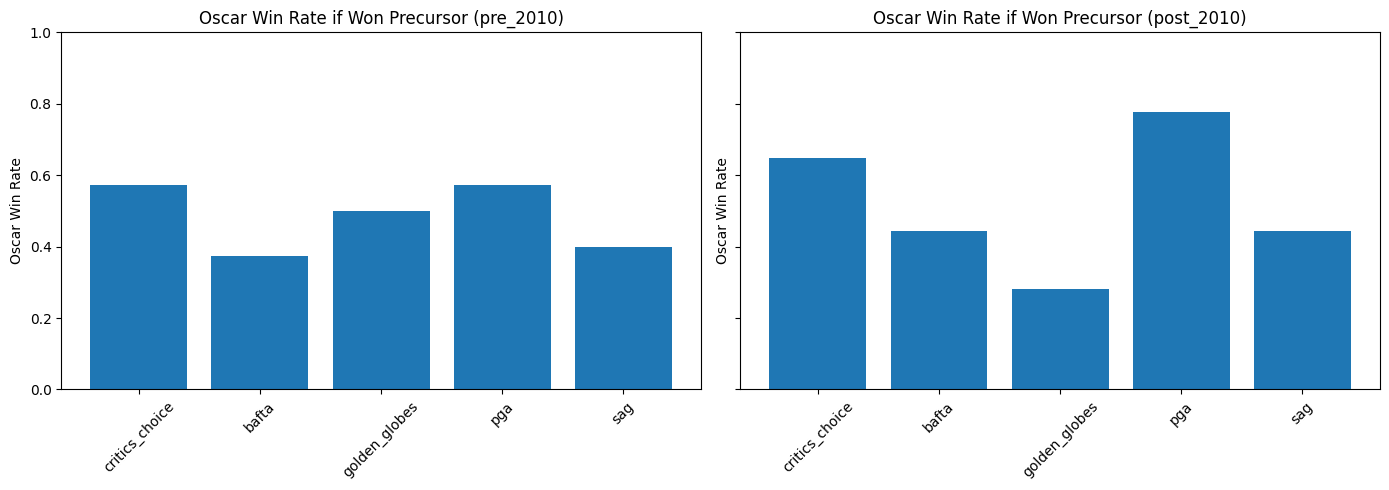

In [13]:
# Same thing but split by era
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, era in zip(axes, ['pre_2010', 'post_2010']):
    era_df = movies[movies['era'] == era]
    rates = {}
    for p in precursors:
        r = era_df.groupby(f'{p}_win')['oscar_win'].mean()
        rates[p] = r.get(1, 0)
    ax.bar(rates.keys(), rates.values())
    ax.set_title(f'Oscar Win Rate if Won Precursor ({era})')
    ax.set_ylabel('Oscar Win Rate')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

   precursor_wins  oscar_win  count
0               0   0.013889    144
1               1   0.111111     36
2               2   0.454545     22
3               3   0.500000     12
4               4   0.571429      7
5               5   1.000000      5


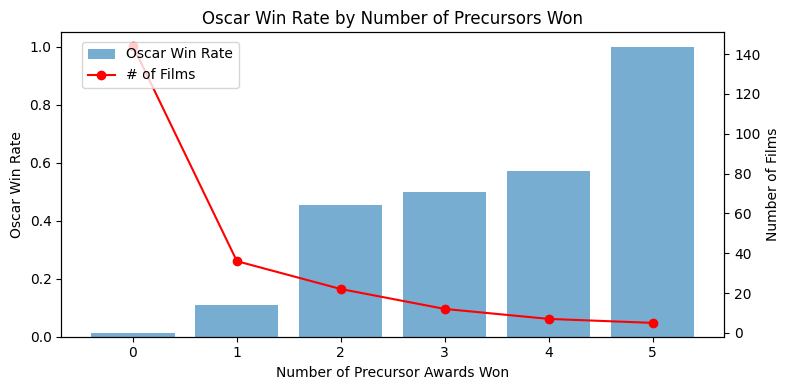

In [ ]:
# how many precursors did each film win?
movies['precursor_wins'] = movies[win_cols].sum(axis=1)

sweep_rates = movies.groupby('precursor_wins')['oscar_win'].mean().reset_index()
sweep_counts = movies.groupby('precursor_wins').size().reset_index(name='count')
sweep = sweep_rates.merge(sweep_counts, on='precursor_wins')
print(sweep)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.bar(sweep['precursor_wins'], sweep['oscar_win'], alpha=0.6, label='Oscar Win Rate')
ax2.plot(sweep['precursor_wins'], sweep['count'], color='red', marker='o', label='# of Films')
ax1.set_xlabel('Number of Precursor Awards Won')
ax1.set_ylabel('Oscar Win Rate')
ax2.set_ylabel('Number of Films')
ax1.set_title('Oscar Win Rate by Number of Precursors Won')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

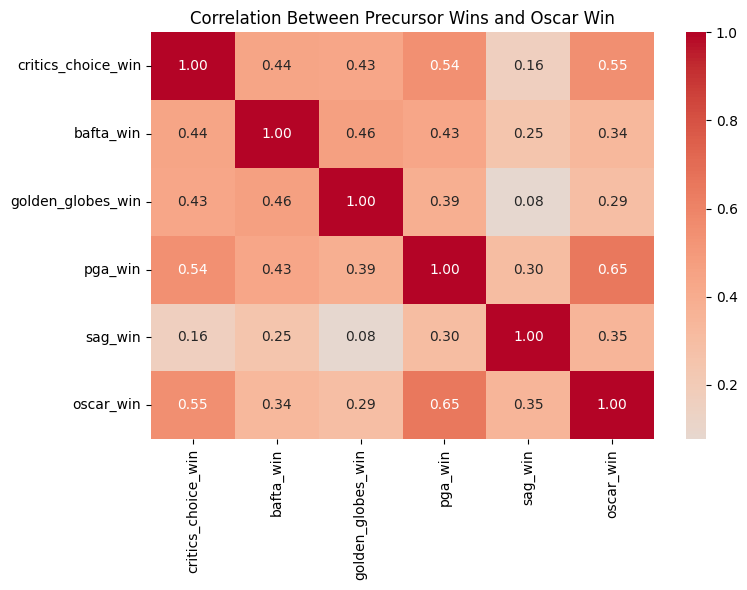

In [ ]:
# Correlation heatmap of all win columns + oscar_win
corr_cols = win_cols + ['oscar_win']
corr = movies[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Precursor Wins and Oscar Win')
plt.tight_layout()
plt.show()

        precursor        era  correct_years  total_years  pct_correct
0  Critics Choice  post_2010             11           17     0.647059
1  Critics Choice   pre_2010              8           14     0.571429
2           Bafta  post_2010              8           17     0.470588
3           Bafta   pre_2010              6           14     0.428571
4   Golden Globes  post_2010              7           17     0.411765
5   Golden Globes   pre_2010              7           14     0.500000
6             Pga  post_2010             14           17     0.823529
7             Pga   pre_2010              8           14     0.571429
8             Sag  post_2010              8           17     0.470588
9             Sag   pre_2010              6           14     0.428571


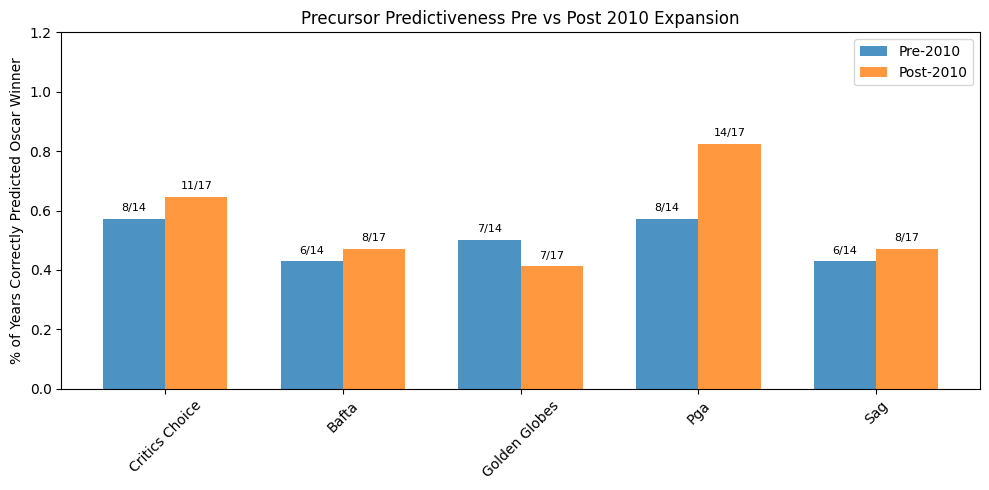

In [21]:
# Count how many years each precursor correctly predicted the Oscar, pre vs post 2010
results = []

for p in precursors:
    for era, era_df in movies.groupby('era'):
        # Films that won this precursor in this era
        precursor_winners = era_df[era_df[f'{p}_win'] == 1]
        
        total_years = era_df['year'].nunique()
        # Years where the precursor winner went on to win the Oscar
        correct_years = precursor_winners.groupby('year')['oscar_win'].max().sum()
        
        results.append({
            'precursor': p.replace('_', ' ').title(),
            'era': era,
            'correct_years': int(correct_years),
            'total_years': total_years,
            'pct_correct': correct_years / total_years
        })

results_df = pd.DataFrame(results)
print(results_df)

# Plot it
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(precursors))
width = 0.35
precursor_labels = [p.replace('_', ' ').title() for p in precursors]

pre = results_df[results_df['era'] == 'pre_2010'].set_index('precursor')
post = results_df[results_df['era'] == 'post_2010'].set_index('precursor')

bars1 = ax.bar([i - width/2 for i in x], 
               [pre.loc[p, 'pct_correct'] for p in precursor_labels], 
               width, label='Pre-2010', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], 
               [post.loc[p, 'pct_correct'] for p in precursor_labels], 
               width, label='Post-2010', alpha=0.8)

# Add the raw correct/total as text on each bar
for bars, era_df in zip([bars1, bars2], [pre, post]):
    for bar, p in zip(bars, precursor_labels):
        correct = int(era_df.loc[p, 'correct_years'])
        total = int(era_df.loc[p, 'total_years'])
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{correct}/{total}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(precursor_labels, rotation=45)
ax.set_ylabel('% of Years Correctly Predicted Oscar Winner')
ax.set_title('Precursor Predictiveness Pre vs Post 2010 Expansion')
ax.set_ylim(0, 1.2)
ax.legend()
plt.tight_layout()
plt.show()